# Fashion-MNIST Baseline Classifier

Goal: understand how 28 by 28 grayscale images become numbers a classifier can learn from.

Prediction before loading data:

- I expect one image to have 28 * 28 = 784 pixel values.
- I expect a batch to include many images at once.


In [22]:
from pickletools import optimize

import torch

In [23]:
# BATCH_SIZE controls how many images the model sees at once.
BATCH_SIZE = 32
LEARNING_RATE = 0.01

## Setup: project paths

This notebook may be run from different working directories.
To avoid saving data in the wrong place, we first find the project root: the folder containing `pyproject.toml`.


In [24]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")


# Find the repo root so saved files go under this project,
# even if the notebook is run from another folder.
project_root = find_project_root(Path.cwd()).resolve()

# torchvision will download Fashion-MNIST under this folder.
data_dir = project_root / "data" / "fashion-mnist"

print(project_root)
print(data_dir)


C:\Users\giloz\dev\intuitive_understanding_machine_learning
C:\Users\giloz\dev\intuitive_understanding_machine_learning\data\fashion-mnist


## Load Fashion-MNIST

Fashion-MNIST is a dataset of small grayscale clothing images.

Each image starts as:

`1 x 28 x 28`

Meaning:

- `1` grayscale channel
- `28` pixel rows
- `28` pixel columns

A batch groups many images together, so a batch of 32 images has shape:

`32 x 1 x 28 x 28`


In [25]:
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor

train_dataset = FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    # ToTensor converts each image into a PyTorch tensor
    # and scales pixel values from 0-255 to 0.0-1.0.
    transform=ToTensor()
)

test_dataset = FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    # Use the same conversion for the test images.
    transform=ToTensor(),
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# DataLoader groups individual examples into batches.
images, labels = next(iter(train_loader))
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")
print(f"First label number: {labels[0].item()}")


Images batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])
First label number: 6


## Inspect one image

Before training, we check one image and label.

The pixel values are scaled to the range `0.0` to `1.0` by `ToTensor()`.
The label is a number, and `train_dataset.classes` maps that number to a clothing name.


In [26]:
class_names = train_dataset.classes

first_image = images[0]
first_label = labels[0]

print(f"First image shape: {first_image.shape}")
print(f"Pixel min: {first_image.min().item():.3f}")
print(f"Pixel max: {first_image.max().item():.3f}")
print(f"Label number: {first_label.item()}")
# class_names maps the numeric label to a clothing category name.
print(f"Label name: {class_names[first_label.item()]}")


First image shape: torch.Size([1, 28, 28])
Pixel min: 0.000
Pixel max: 1.000
Label number: 6
Label name: Shirt


## Save sample images

The saved image grid is our first required artifact.

We use `squeeze()` because one image has shape `[1, 28, 28]`, but `imshow` expects the visible pixel grid as `[28, 28]`.


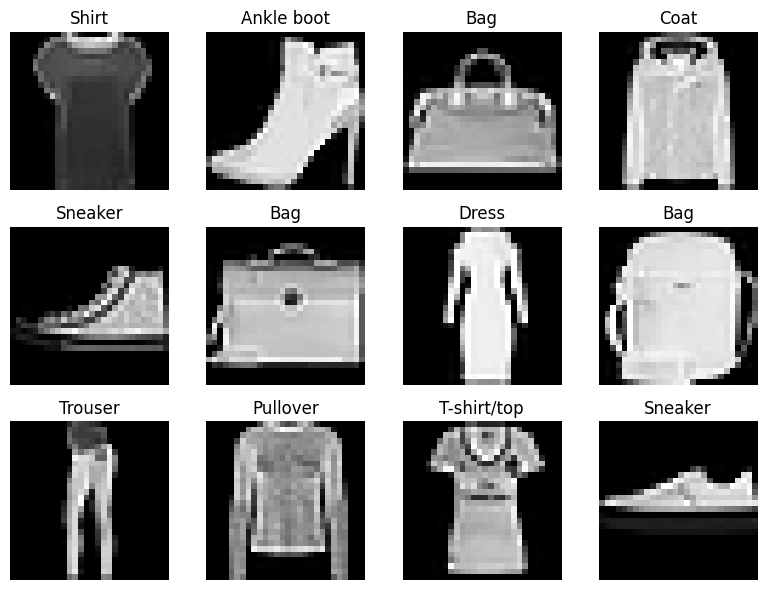

Saved sample image grid to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-06-image-classification-baseline\sample_images.png


In [27]:
import matplotlib.pyplot as plt

artifacts_dir = project_root / "artifacts" / "week-06-image-classification-baseline"
artifacts_dir.mkdir(parents=True, exist_ok=True)

sample_images_path = artifacts_dir / "sample_images.png"

fig, axes = plt.subplots(3, 4, figsize=(8,6))

for axis, image, label in zip(axes.ravel(), images[:12], labels[:12]):
    # Remove the single grayscale channel dimension:
    # [1, 28, 28] -> [28, 28]
    axis.imshow(image.squeeze(), cmap="gray")
    axis.set_title(class_names[label.item()])
    axis.axis("off")

fig.tight_layout()
fig.savefig(sample_images_path, dpi=150)
plt.show()

print(f"Saved sample image grid to: {sample_images_path}")


## Baseline model: flatten then linear

The simplest baseline model treats the image as 784 input numbers:

`1 * 28 * 28 = 784`

Shape story:

`[32, 1, 28, 28] -> [32, 784] -> [32, 10]`

The final `10` means one raw score for each clothing class.

These raw scores are called **logits**. They are not probabilities yet: they can be negative, positive, smaller than `0`, or larger than `1`.

Later, `CrossEntropyLoss` will compare these logits with the true label.


In [28]:
from torch import nn

class FashionMNISTBaseline(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        # Flatten changes each image from [1, 28, 28] to [784].
        self.flatten = nn.Flatten()
        # Linear maps 784 input pixel values to 10 class scores.
        self.linear = nn.Linear(in_features=28 * 28, out_features=10)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        flattened_images = self.flatten(images)
        class_scores = self.linear(flattened_images)
        return class_scores

model = FashionMNISTBaseline()

with torch.no_grad():
    scores = model(images)

print(f"Input batch shape: {images.shape}")
print(f"Output scores shape: {scores.shape}")
print(f"Scores for first image: {scores[0]}")


Input batch shape: torch.Size([32, 1, 28, 28])
Output scores shape: torch.Size([32, 10])
Scores for first image: tensor([ 0.1043, -0.0364, -0.2068,  0.0635, -0.1973,  0.0322, -0.1072, -0.0797,
         0.0411,  0.1578])


## One-batch training sanity check

Before training for full epochs, I will test one learning step on one batch.

The model outputs logits shaped `[32, 10]`: one row per image, one raw score per class.

The labels are shaped `[32]`: one correct class number per image.

`CrossEntropyLoss` is the right loss here because each Fashion-MNIST image belongs to exactly one class.

In simple terms:

`cross entropy = -log(probability assigned to the correct class)`

So if the model gives the true class high probability, loss is low. If it gives the true class low probability, loss is high.

PyTorch detail: I should pass raw logits into `nn.CrossEntropyLoss()`, not softmax probabilities. PyTorch applies the needed softmax-like calculation internally.

Expected result:
The loss after one optimizer step may be slightly lower, but it does not have to improve perfectly from one batch.


In [35]:
# CrossEntropyLoss compares raw class scores (logits) with true class numbers.
# Use this for exactly-one-class classification.
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

model.train()

scores_before = model(images)
loss_before = loss_fn(scores_before, labels)

optimizer.zero_grad()
loss_before.backward()
optimizer.step()

scores_after = model(images)
loss_after = loss_fn(scores_after, labels)

print(f"Loss before one update: {loss_before.item():.4f}")
print(f"Loss after one update: {loss_after.item():.4f}")


Loss before one update: 2.0629
Loss after one update: 2.0265
